In [2]:
import pandas as pd

scraped_df = pd.read_csv("../data/scraped/scraped_airbnb.csv")

scraped_df.head()

,url,title,price,rating,reviews,superhost,guest_favorite,city
0,https://www.airbnb.com/rooms/17037295913997473...,Amsterdam City - Rooftop Houseboat,129118.0,5.0,55.0,True,True,Amsterdam
1,https://www.airbnb.com/rooms/17226577502388518...,Beautiful waterfront studio,53665.0,NaN,NaN,True,False,Amsterdam
2,https://www.airbnb.com/rooms/17217063826480356...,Comfort private room in the city center,41363.0,NaN,NaN,True,False,Amsterdam
3,https://www.airbnb.com/rooms/17227175490672516...,Lovely Apartment with Parking,NaN,NaN,NaN,True,False,Amsterdam
4,https://www.airbnb.com/rooms/15724705563281536...,Conscious Hotel Vondelpark,35893.0,NaN,NaN,True,False,Amsterdam


In [3]:
scraped_df.shape

(222, 8)

In [4]:
scraped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             222 non-null    object 
 1   title           220 non-null    object 
 2   price           188 non-null    float64
 3   rating          68 non-null     float64
 4   reviews         68 non-null     float64
 5   superhost       222 non-null    bool   
 6   guest_favorite  222 non-null    bool   
 7   city            222 non-null    object 
dtypes: bool(2), float64(3), object(3)
memory usage: 11.0+ KB


In [5]:
scraped_df.columns.tolist()

['url',
 'title',
 'price',
 'rating',
 'reviews',
 'superhost',
 'guest_favorite',
 'city']

In [6]:
scraped_df.isnull().sum()

url                 0
title               2
price              34
rating            154
reviews           154
superhost           0
guest_favorite      0
city                0
dtype: int64

In [7]:
(
    scraped_df.isnull().mean() * 100
).round(2)

url                0.00
title              0.90
price             15.32
rating            69.37
reviews           69.37
superhost          0.00
guest_favorite     0.00
city               0.00
dtype: float64

In [8]:
scraped_df.duplicated().sum()

np.int64(0)

In [9]:
scraped_df["url"].duplicated().sum()

np.int64(0)

In [10]:
scraped_df["price"].describe()

count    1.880000e+02
mean     8.170319e+04
std      2.149908e+05
min      1.791200e+04
25%      3.551450e+04
50%      4.934650e+04
75%      7.697950e+04
max      2.683440e+06
Name: price, dtype: float64

In [11]:
scraped_df["rating"].describe()

count    68.000000
mean      4.950441
std       0.058372
min       4.730000
25%       4.920000
50%       4.970000
75%       5.000000
max       5.000000
Name: rating, dtype: float64

In [12]:
scraped_df["reviews"].describe()

count    6.800000e+01
mean     1.161017e+06
std      4.557876e+06
min      5.500000e+01
25%      1.994750e+03
50%      6.464000e+03
75%      1.741740e+05
max      2.783278e+07
Name: reviews, dtype: float64

In [13]:
scraped_df["superhost"].value_counts()

superhost
True     220
False      2
Name: count, dtype: int64

In [14]:
scraped_df["city"].value_counts()

city
Amsterdam    28
Barcelona    28
Berlin       28
Lisbon       28
London       28
Rome         28
Athens       18
Budapest     18
Vienna       18
Name: count, dtype: int64

<Axes: >

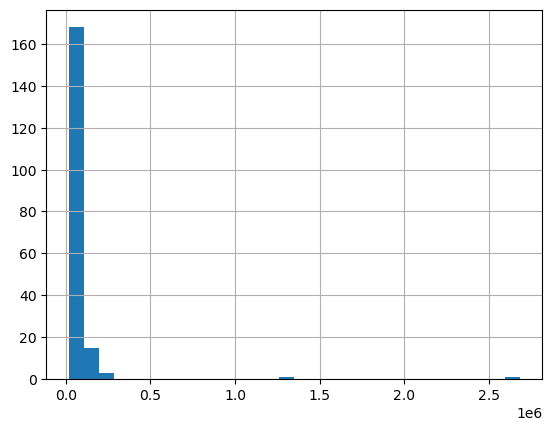

In [15]:
scraped_df["price"].hist(
    bins=30
)

<Axes: >

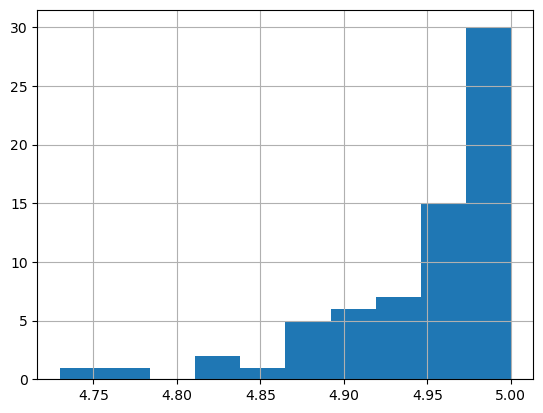

In [16]:
scraped_df["rating"].hist()

<Axes: >

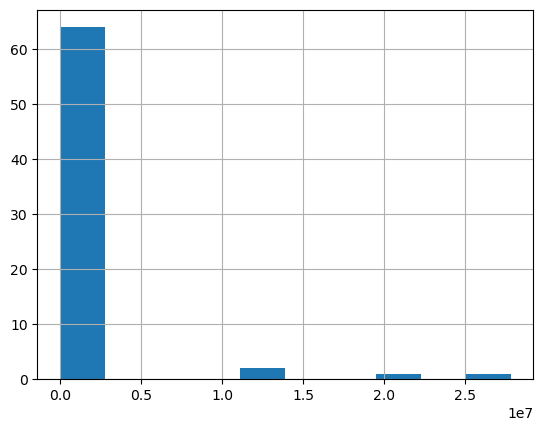

In [17]:
scraped_df["reviews"].hist()

In [18]:
scraped_df.sample(10)

,url,title,price,rating,reviews,superhost,guest_favorite,city
139,https://www.airbnb.com/rooms/17203559931833572...,"By the Castle, Stylish & Comfy, Family-Friendly",43477.0,NaN,NaN,True,False,Lisbon
165,https://www.airbnb.com/rooms/16925884739904654...,Quiet 3BR 2 Bath Luxe Duplex w/ A/C + Free Par...,91579.0,NaN,NaN,True,False,London
102,https://www.airbnb.com/rooms/14162416?search_m...,Lovely apartment in the heart of Budapest,20442.0,4.98,379379.0,True,False,Budapest
59,https://www.airbnb.com/rooms/17100455665494041...,Sweett | Rocafort 101,85184.0,NaN,NaN,True,False,Barcelona
127,https://www.airbnb.com/rooms/16426707693073526...,"Elegant 3BR Lapa Residence | Balcony, AC & Par...",97540.0,5.00,1010.0,True,True,Lisbon
125,https://www.airbnb.com/rooms/12231860706693663...,Central Lisbon Luxury | Walk to Everything,51061.0,4.96,121121.0,True,True,Lisbon
57,https://www.airbnb.com/rooms/14717332981803378...,The Social Hub Barcelona Poblenou,49337.0,NaN,NaN,True,False,Barcelona
149,https://www.airbnb.com/rooms/14629458833622808...,Studios2Let Bloomsbury,NaN,NaN,NaN,True,False,London
213,https://www.airbnb.com/rooms/17166020188627773...,Stylish Apartment up to 14 I Close to AKH and U6,40415.0,NaN,NaN,True,False,Vienna
204,https://www.airbnb.com/rooms/17224282396085380...,cityswap- Bright Apt.2 · AC · Vienna 3rd District,162096.0,NaN,NaN,True,False,Vienna


In [20]:
correlation_matrix = (
    scraped_df
    .corr(numeric_only=True)
    .round(2)
)

display(correlation_matrix)

,price,rating,reviews,superhost,guest_favorite
price,1.00,-0.07,-0.03,0.01,0.11
rating,-0.07,1.00,-0.51,NaN,-0.27
reviews,-0.03,-0.51,1.00,NaN,0.16
superhost,0.01,NaN,NaN,1.00,0.05
guest_favorite,0.11,-0.27,0.16,0.05,1.00
